Prediction : Fail
0.0
0.0
0.5
0.0
0.0
0.0
0.0


C:\Users\bs594\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
C:\Users\bs594\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
C:\Users\bs594\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

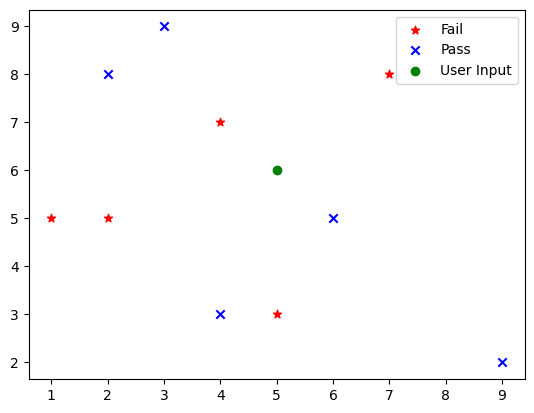

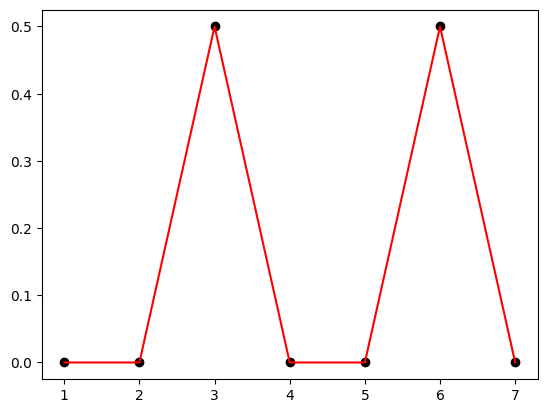

Index(['Study', 'Sleep'], dtype='object')


In [3]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score,precision_score,f1_score
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif

Data = pd.DataFrame({
    "Study":[2,4,5,7,1,3,6,4,9,2],
    "Sleep":[5,7,3,8,5,9,5,3,2,8],
    "Result":[0,0,0,0,0,1,1,1,1,1]
    })

x = Data[['Study','Sleep']]
y= Data['Result']

model = KNeighborsClassifier(n_neighbors=3)
model.fit(x,y)

prediction=model.predict([[5,6]])
probablity = model.predict_proba([[5,6]])
if(prediction[0]==1):
    print("Predictioin : pass")
else:
    print("Prediction : Fail")

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
k_values=[]
accuracy =[]
for k in range(1,len(x_train+1)):
    model=KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train,y_train)
    y_prediction=model.predict(x_test)
    acc = accuracy_score(y_test,y_prediction)
    precision=precision_score(y_test,y_prediction)
    print(precision)
    k_values.append(k)
    accuracy.append(acc)

plt.scatter(x[y==0]['Study'],x[y==0]['Sleep'],color='Red',marker='*',label='Fail')
plt.scatter(x[y==1]['Study'],x[y==1]['Sleep'],color='blue',marker='x',label='Pass')
plt.scatter(5,6,color='green',marker='o',label='User Input')
plt.legend()
plt.show()

plt.scatter(k_values,accuracy,color='black',marker='o')
plt.plot(k_values,accuracy,color='red')
plt.show()

selector = SelectKBest(score_func=f_classif,k=2)
X_new = selector.fit_transform(x,y)
print(x.columns[selector.get_support()])